In [148]:
from typing import Annotated
from typing_extensions import TypedDict


from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver # for RAM

from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph
from langgraph.graph import StateGraph, START

from IPython.display import display, Image

In [149]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [150]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    
llm = ChatOpenAI(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROK_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

In [151]:
def chatbot(state : State):
    response = llm.invoke(state['messages'])
    return {
        'messages' : [response]
    }

In [152]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")

### Creating Memory

In [153]:
memory = InMemorySaver()
graph = builder.compile(checkpointer = memory)

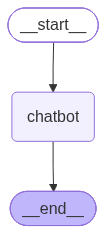

In [154]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Create thread Configuration

In [155]:
config = {
    "configurable" : {
        "thread_id" : "thread-1"
    }
}
config

{'configurable': {'thread_id': 'thread-1'}}

### First Invocation

In [156]:
result = graph.invoke(
    {
        "messages" : [
            HumanMessage(content = "Hi, I am Amandeep")
        ]
    },
    config = config
)
print("\n Returned State")
for msg in result["messages"]:
    print(f"{msg.type} : {msg.content}")


 Returned State
human : Hi, I am Amandeep
ai : Hello Amandeep! It's nice to meet you. Is there something I can help you with or would you like to chat?


### Latest Checkpoint

In [157]:
state = graph.get_state(config)
state # it will print latest checkpoint

StateSnapshot(values={'messages': [HumanMessage(content='Hi, I am Amandeep', additional_kwargs={}, response_metadata={}, id='aadcd47a-807e-4704-b38d-70c1641e7c58'), AIMessage(content="Hello Amandeep! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 43, 'total_tokens': 72, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.052628165, 'prompt_time': 0.001957544, 'completion_time': 0.050010355, 'total_time': 0.051967899}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-942e516f-07f5-4b35-bafa-1e830205dceb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f8365-5736-7ec2-802c-e90a9c69d707-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 29, 'total

### Second Invocation

In [158]:
result = graph.invoke(
    {
        "messages" : [
            HumanMessage(content = "What is my name?")
        ]
    },
    config = config
)
print("\n Returned State")
for msg in result["messages"]:
    print(f"{msg.type} : {msg.content}")


 Returned State
human : Hi, I am Amandeep
ai : Hello Amandeep! It's nice to meet you. Is there something I can help you with or would you like to chat?
human : What is my name?
ai : Your name is Amandeep.


### Latest Checkpoint

In [159]:
state = graph.get_state(config)
state

StateSnapshot(values={'messages': [HumanMessage(content='Hi, I am Amandeep', additional_kwargs={}, response_metadata={}, id='aadcd47a-807e-4704-b38d-70c1641e7c58'), AIMessage(content="Hello Amandeep! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 43, 'total_tokens': 72, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.052628165, 'prompt_time': 0.001957544, 'completion_time': 0.050010355, 'total_time': 0.051967899}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-942e516f-07f5-4b35-bafa-1e830205dceb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f8365-5736-7ec2-802c-e90a9c69d707-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 29, 'total

### Checkpoint History

In [160]:
history = graph.get_state_history(config)
for checkpoint in history:
    print(checkpoint)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, I am Amandeep', additional_kwargs={}, response_metadata={}, id='aadcd47a-807e-4704-b38d-70c1641e7c58'), AIMessage(content="Hello Amandeep! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 43, 'total_tokens': 72, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.052628165, 'prompt_time': 0.001957544, 'completion_time': 0.050010355, 'total_time': 0.051967899}, 'model_provider': 'openai', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'id': 'chatcmpl-942e516f-07f5-4b35-bafa-1e830205dceb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f8365-5736-7ec2-802c-e90a9c69d707-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 29, 'total